<a href="https://colab.research.google.com/github/agus-beep952/Estadisticaverano2026/blob/main/UNIDAD%203/Copia_de_Practica01U3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 01 para series de tiempo

Para esta práctica, se utilizará la librería `yfinance`, la cual permite obtener datos históricos de mercados financieros directamente desde Yahoo Finance. Esta herramienta es de uso gratuito y no requiere el uso de claves de acceso (API keys), lo que la hace especialmente conveniente para fines educativos.

Los datos obtenidos mediante `yfinance` corresponden a información real del mercado financiero. Sin embargo, es importante considerar que esta herramienta no constituye una fuente oficial de datos, por lo que puede presentar limitaciones en cuanto a disponibilidad, consistencia o actualización. Para fines académicos y de análisis exploratorio, estos datos son adecuados; no obstante, para aplicaciones profesionales o decisiones financieras, se recomienda el uso de fuentes oficiales o servicios especializados.

Adicionalmente, `yfinance` no es una API oficial, por lo que en ocasiones puede presentar fallas temporales en la descarga de datos.

Los principales argumentos que requiere yfinance para realizar la descarga son:

+ `tickers`: Los tickers son identificadores únicos de activos financieros (por ejemplo, acciones) en los mercados. Por ejemplo, `AAPL` corresponde a Apple, `TSLA` a Tesla y `MSFT` a Microsoft. Si quieres inspeccionar tickers [pulsa aquí](https://www.nasdaq.com/market-activity/stocks/screener) y se te abrirá un catálogo de diversas multinacionales.
+ `start`: Fecha de inicio para la descarga de datos en formato `YYYY-mm-dd` que significa: cuatro dígitos para el año (`YYYY`), dos dígitos para el mes (`mm`) y dos dígitos para el día (`dd`) en ese orden.
+ `end`: Fecha de fin para la descarga de datos siguiendo también un formato `YYYY-mm-dd`.
+ `interval`: Define la frecuencia de los datos. Por ejemplo, `"1d"` indica datos diarios, `"1wk"` semanales y `"1mo"` mensuales.
+ `group_by`: Define la forma en que se organizan las columnas cuando se descargan datos de uno o varios tickers. Por ejemplo, `group_by="column"` organiza la información por tipo de variable (Open, High, Low, Close, etc.), mientras que `group_by="ticker"` agrupa primero por activo financiero.
+ `auto_adjust`: Si se establece en `True`, los precios se ajustan automáticamente considerando dividendos y divisiones de acciones. Si es `False`, se mantienen los valores originales.
+ `actions`: Permite incluir información adicional como dividendos y divisiones de acciones cuando se establece en `True`.
+ `progress`: Controla si se muestra o no una barra de progreso durante la descarga.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# Link para inspeccionar tickers:
# https://www.nasdaq.com/market-activity/stocks/screener

# Obtener datos de acciones
df = yf.download(
    tickers="TSLA",          # AAPL: Apple, TSLA: Tesla, MSFT: Microsoft, etc.
    start="2024-07-01",      # Fecha de inicio
    end="2026-07-20",        # Fecha de fin
    interval="1d",           # Intervalo de tiempo: 1 día
    group_by="column",       # Forma estándar de organizar las columnas
    auto_adjust=False,       # False conserva columnas como Close y Adj Close
    actions=False,           # True incluiría dividendos y divisiones de acciones
    progress=False           # Evita mostrar barra de progreso
)

# Verificar si la descarga fue exitosa
if df.empty:
    raise ValueError(
        "No se descargaron datos. Verifica que el ticker sea correcto "
        "o intenta nuevamente más tarde."
    )

# Paso 1: Mover 'Date' del índice a columna regular
df = df.reset_index()

# Paso 2: Aplanar columnas si vienen como MultiIndex
# Esto puede ocurrir dependiendo de la versión de yfinance/pandas.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        "_".join([str(valor) for valor in columna if valor != ""]).strip()
        for columna in df.columns
    ]

# Reemplazar espacios por _
df.columns = [i.replace(" ", "_") for i in df.columns]

# Paso 3:
#######################################################
## En caso de que no se requiera la hora

# Convertir la columna 'Date' a tipo datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

df

,Date,Adj_Close_TSLA,Close_TSLA,High_TSLA,Low_TSLA,Open_TSLA,Volume_TSLA
0,2024-07-01,209.860001,209.860001,213.229996,200.850006,201.020004,135691400
1,2024-07-02,231.259995,231.259995,231.300003,218.059998,218.889999,205047900
2,2024-07-03,246.389999,246.389999,248.350006,234.250000,234.559998,166561500
3,2024-07-05,251.520004,251.520004,252.369995,242.460007,249.809998,154501200
4,2024-07-08,252.940002,252.940002,259.440002,244.570007,247.710007,157219600
...,...,...,...,...,...,...,...
508,2026-07-13,394.760010,394.760010,405.570007,391.369995,404.609985,32809200
509,2026-07-14,396.179993,396.179993,402.220001,394.760010,399.049988,23385000
510,2026-07-15,394.459991,394.459991,406.589996,390.660004,399.399994,31549800
511,2026-07-16,391.059998,391.059998,395.309998,385.320007,392.350006,29269100


Una vez extraida la información, tenemos un DataFrame con las siguientes variables:

+ `Date`: Fecha correspondiente a cada registro de la serie de tiempo.
+ `Open_AAPL`: Precio de apertura de la acción al inicio de la jornada.
+ `High_AAPL`: Precio máximo alcanzado por la acción durante el intervalo de tiempo seleccionado.
+ `Low_AAPL`: Precio mínimo registrado durante el intervalo de tiempo seleccionado.
+ `Close_AAPL`: Precio de cierre de la acción al final del intervalo de tiempo seleccionado.
+ `Adj_Close_AAPL`: Precio de cierre ajustado, el cual incorpora efectos de dividendos y divisiones de acciones, proporcionando una medida más consistente para análisis históricos.
+ `Volume_AAPL`: Número total de acciones negociadas durante el día (volumen de transacciones).

En las series de tiempo `x` siempre es la variable temporal, en esta caso `Date`, mientras que `y` puede ser cualquiera de las restantes, dependiendo de lo que se esté analizando. En este caso recomiendo usar `Adj_Close_APPL` debido a que es la que incorpora más información.

Primero se debe revisar el DataFrame para asegurarnos de que las variables son del tipo adecuado (sin variables tipo `object`).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            513 non-null    datetime64[ns]
 1   Adj_Close_TSLA  513 non-null    float64       
 2   Close_TSLA      513 non-null    float64       
 3   High_TSLA       513 non-null    float64       
 4   Low_TSLA        513 non-null    float64       
 5   Open_TSLA       513 non-null    float64       
 6   Volume_TSLA     513 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 28.2 KB


Ahora se declara `x` y `y`.

In [ ]:
x = df["Date"]
y = df['Adj_Close_TSLA']

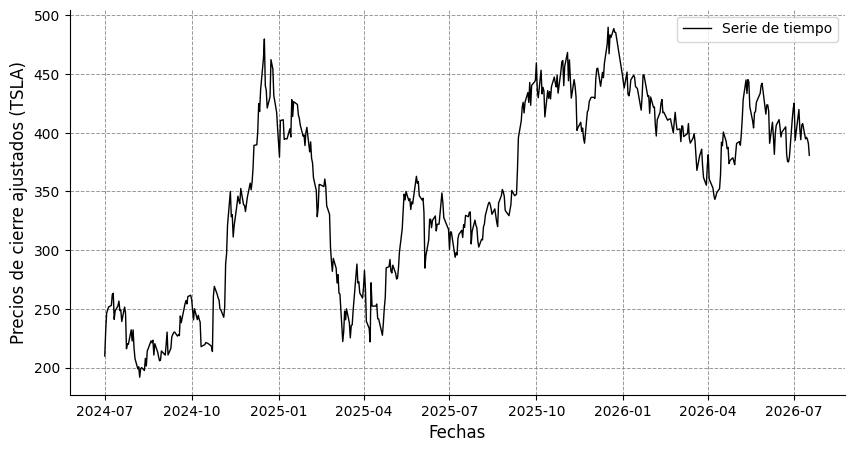

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de cierre ajustados (TSLA)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



## Métodos de promedios móviles

**Ejercicio 1**: Aplica una media móvil simple (SMA) a la serie de tiempo. Prueba con distintos tamaños de ventana (`window`) y selecciona uno que consideres adecuado. Justifica tu elección con base en el comportamiento observado en la serie.

Ten en cuenta que la serie de tiempo no incluye sábados ni domingos; por lo tanto, aproximadamente:

+ 5 observaciones corresponden a una semana
+ 21 observaciones a un mes
+ 252 observaciones a un año

Una vez termines, borra estas instrucciones y redacta tus observaciones.


In [ ]:
# Promedio Móvil Simple
df['Adj_Close_TSLA_SMA'] = df['Adj_Close_TSLA'].rolling(window=30).mean()

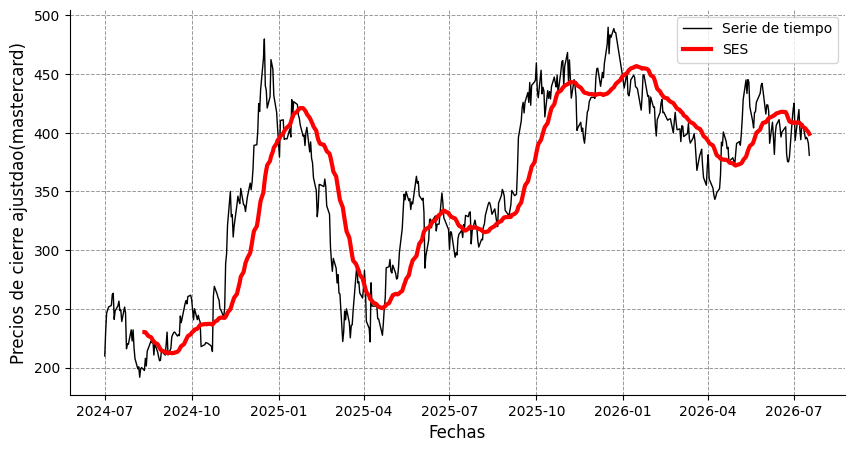

In [ ]:

# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["Adj_Close_TSLA_SMA"],
    color='red',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='SES'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de cierre ajustdao(mastercard)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

## Método de suavisación exponencial

**Ejercicio 2**: Aplica una suavización exponencial simple (SES) a la serie de tiempo. Prueba con distintos valores del parámetro de suavizamiento (por ejemplo, mediante span o alpha) y selecciona uno que consideres adecuado. Justifica tu elección con base en el comportamiento observado en la serie.

Ten en cuenta que la serie de tiempo no incluye sábados ni domingos; por lo tanto, aproximadamente:

+ 5 observaciones corresponden a una semana
+ 21 observaciones a un mes
+ 252 observaciones a un año

Una vez termines, borra estas instrucciones y redacta tus observaciones.

In [ ]:
df['Adj_Close_TSLA_SES'] = df['Adj_Close_TSLA'].ewm(span=30, adjust=False).mean()

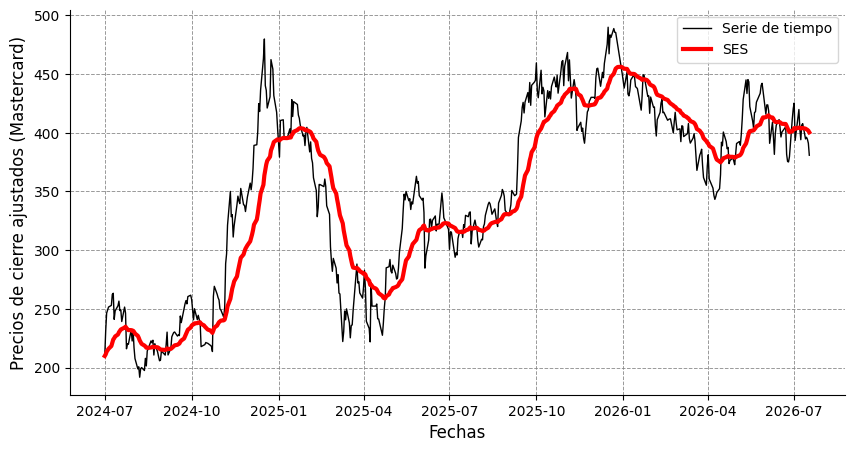

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["Adj_Close_TSLA_SES"],
    color='red',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='SES'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de cierre ajustados (Mastercard)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)


**Ejercicio 3**: Observando las curvas por SMA y SES, señala las ventajas y desventajas que puedes observar en ambos gráficos.

Una vez termines, borra estas instrucciones y redacta tus observaciones.

Al comparar ambas gráficas, se observa que las dos técnicas logran suavizar las fluctuaciones de la serie de precios y permiten identificar la tendencia general. Sin embargo, existen diferencias importantes en su comportamiento.

La curva del SMA (Promedio Móvil Simple) presenta un suavizado mayor, por lo que las variaciones bruscas de los precios se ven más atenuadas. Esto facilita visualizar la tendencia de largo plazo, pero provoca un retraso más notable respecto a la serie original, especialmente durante los cambios rápidos de tendencia, como las caídas y recuperaciones observadas entre enero y abril de 2025.

En cambio, la curva del SES (Suavizamiento Exponencial Simple) sigue más de cerca a la serie real. En la gráfica, el SES reacciona con mayor rapidez a los aumentos y disminuciones de los precios, debido a que asigna más peso a las observaciones recientes. Como resultado, el ajuste es más cercano a los datos originales y presenta menor desfase que el SMA.

En conclusión, la gráfica de SMA muestra una tendencia más estable y suave, aunque con mayor retraso frente a los movimientos reales del mercado, mientras que la gráfica de SES refleja mejor los cambios recientes y proporciona una representación más dinámica de la evolución de los precios.

## Tendencias no lineales

**Ejercicio 4**: Realiza una regresión polinomial de grado 2. Usa series de Fourier para extraer la estacionalidad y calcular el ruido de medición. Apóyate en los gráficos correspondientes y analiza las longitudes de onda para establecer si existe estacionalidad. Ten en cuenta que la serie de tiempo no incluye sábados ni domingos; por lo tanto, aproximadamente:

+ 5 observaciones corresponden a una semana
+ 21 observaciones a un mes
+ 252 observaciones a un año

Una vez termines, borra estas instrucciones y redacta tus observaciones.

In [ ]:
from numpy.polynomial.polynomial import Polynomial
X = pd.to_datetime(df["Date"]).map(pd.Timestamp.timestamp)
grado = 5
modelo = Polynomial.fit(X, y, deg = grado)
df['tendencia_polinomial'] = modelo(X)
df['ruido_polinomial'] = y - df['tendencia_polinomial']

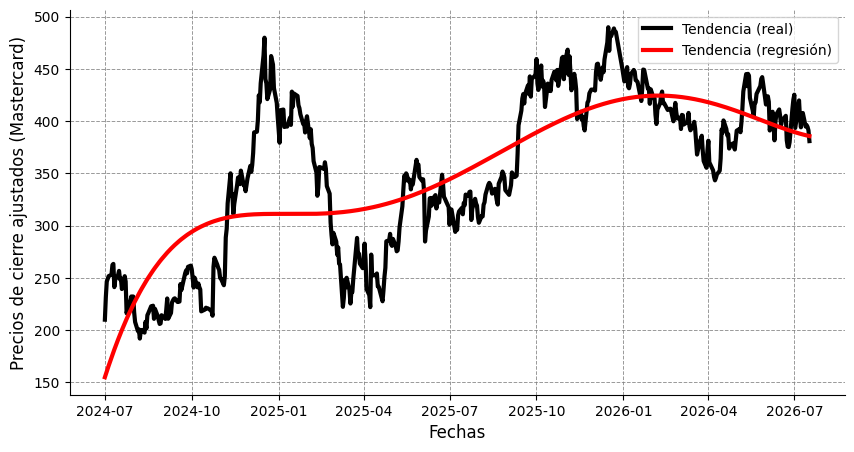

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)


# --- Gráfico de línea ---
plt.plot(
    x, df["Adj_Close_TSLA"],
    color='black',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (real)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia_polinomial"],
    color='red',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (regresión)'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de cierre ajustados (Mastercard)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



## Análisis de los componentes de la serie

**Ejercicio 5**: Apóyate de los gráficos correspondientes para analizar cada uno de los componentes de la serie por separado. Comenta lo que se puede observar de cada componente, si crees que se pudo aproximar bien o no, y por qué.

Una vez termines, borra estas instrucciones y redacta tus observaciones.

In [ ]:
df["ruido_estacionalidad_poliminal"] = y-df["tendencia_polinomial"]

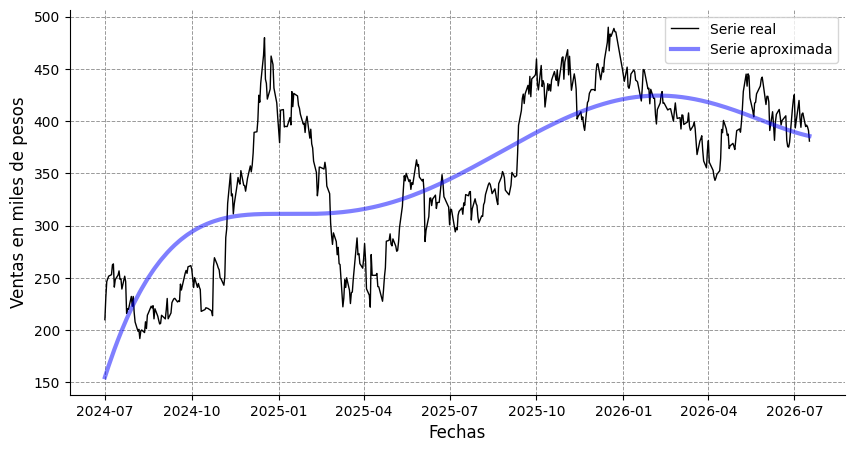

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada',
    alpha = 0.5
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

In [ ]:
serie_real = y
serie_aproximada = df["tendencia_polinomial"]

In [ ]:
# Aquí no le muevan a nada
# Básicamente, lo que se hace este bloque es crear la función
# Transformada_de_Fourier, puesto a que no existe para lo que la quiero usar.

def Transformada_de_Fourier(serie, terminos, un_grafico):
  '''La función acepta los argumentos "serie", la cual debe de ser un array
  en numpy y en pandas de la forma df["my_variable"].values. Por otra parte,
  el parámetro "terminos" es un número natural que indica la cantidad de
  términos que desarrolla la serie. Entre mayor sea el número de términos,
  la serie será más precisa, pero más difícil de interpretar.

  La función tiene como salida una lista con los componentes sinosoidales de serie.
  El último elemento de la lista, es la suma de todos los componentes'''

  import numpy as np
  import matplotlib.pyplot as plt
  import pandas as pd
  from scipy.fftpack import fft, ifft

  # Supongamos que tienes una serie en df['AAPL_Close']
  # Reemplaza esta línea con tu DataFrame y serie específicos
  n = len(serie)

  # Calcular la transformada de Fourier
  transformada_fourier = fft(serie)

  # Obtener las frecuencias
  frecuencias = np.fft.fftfreq(n)

  # Crear un DataFrame para almacenar la frecuencia y su magnitud
  componentes = pd.DataFrame({
      'frecuencia': frecuencias,
      'magnitud': np.abs(transformada_fourier),
      'longitud_de_onda': 1 / frecuencias
  })

  # Ordenar el dataframe de mayor a menor en términos de magnitud

  componentes = componentes.sort_values(by='magnitud', ascending=False)

  # Seleccionar las frecuencias con mayor magnitud (excluyendo la frecuencia cero)
  top_frecuencias = componentes.loc[componentes['frecuencia'] > 0].nlargest(terminos, 'magnitud')
  top_frecuencias.reset_index(drop=True, inplace=True)
  print("Frecuencias principales:\n", top_frecuencias)

  # Crear el índice de tiempo para la serie
  t = np.arange(n)

  # Graficar cada componente de frecuencia junto con la serie original
  plt.figure(figsize=(12, 4))

  componente_temporal_sumado = np.zeros_like(serie)
  componentes_temporales = []

  n=0
  for i, row in top_frecuencias.iterrows():
      n+=1
      # Copiar la transformada de Fourier y mantener solo la frecuencia actual
      fourier_component = np.zeros_like(transformada_fourier)
      idx = np.where(frecuencias == row['frecuencia'])[0][0]  # índice de la frecuencia en la FFT
      fourier_component[idx] = transformada_fourier[idx]  # mantener solo la frecuencia positiva
      fourier_component[-idx] = transformada_fourier[-idx]  # mantener la frecuencia negativa correspondiente
      if n == (terminos+1):
        break

      # Reconstruir la señal en el tiempo
      componente_temporal = ifft(fourier_component).real
      componentes_temporales.append(componente_temporal)
      componente_temporal_sumado += componente_temporal

      # Graficar la componente
      plt.plot(
          componente_temporal,
          label=f'Longitud de onda {1 / row["frecuencia"]:.0f}',
          alpha=1,
          linewidth = 0.5,
          )
      plt.title('Componentes de Fourier de la Serie')
      plt.xlabel('Tiempo')
      plt.ylabel('Valor')
      plt.legend()
      plt.grid()

  componentes_temporales.append(componente_temporal_sumado)
  plt.plot(serie, label='Serie Original', color='black', alpha=0.5)
  if not un_grafico:
    plt.figure(figsize=(12, 4))
    plt.plot(serie, label='Serie Original', color='black', alpha=0.5)
  plt.plot(componente_temporal_sumado, label='Componente temporal sumada', color='red')
  plt.legend()
  plt.title('Suma de los Componentes de Fourier de la Serie')
  plt.xlabel('Tiempo')
  plt.ylabel('Valor')
  plt.grid()
  plt.show()

  return componente_temporal_sumado

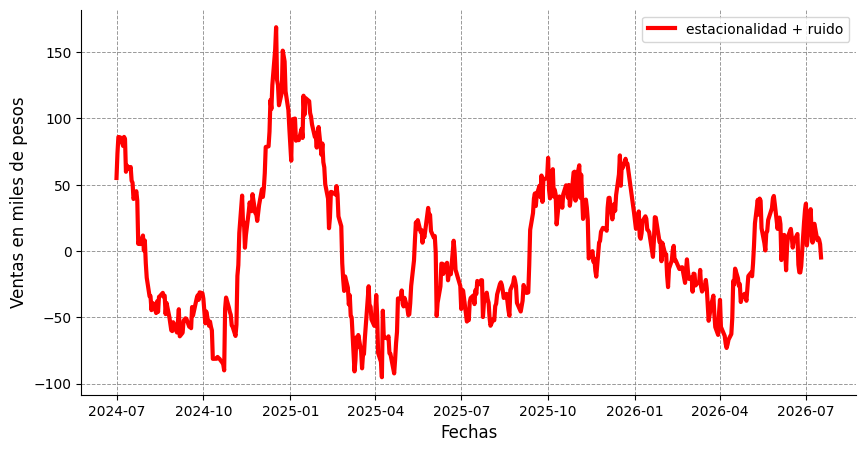

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)


# --- Gráfico de línea ---
plt.plot(
    x, df["ruido_polinomial"],
    color='red',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='estacionalidad + ruido'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



Frecuencias principales:
    frecuencia     magnitud  longitud_de_onda
0    0.007797  9285.089208            128.25
1    0.005848  8966.472674            171.00
2    0.003899  6293.717657            256.50
3    0.009747  6051.881648            102.60
4    0.011696  4438.985653             85.50


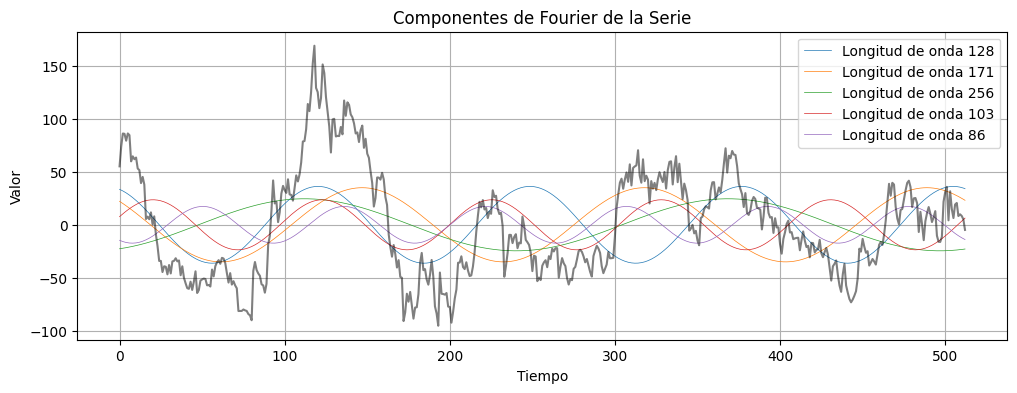

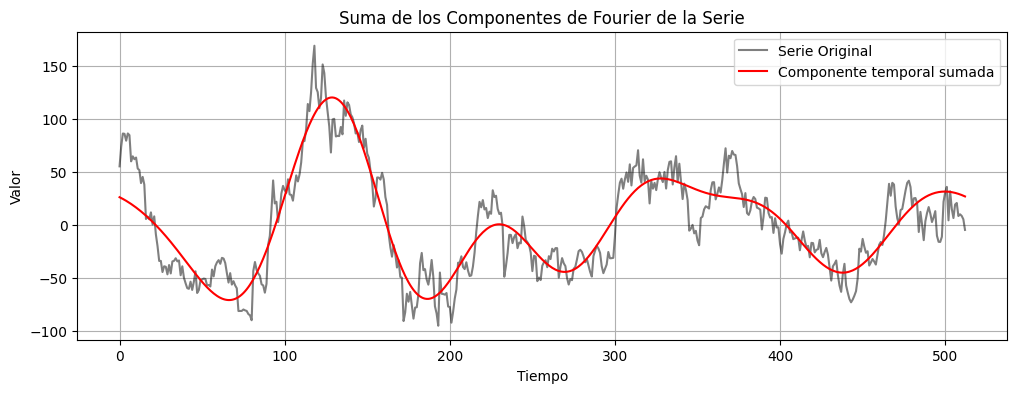

In [ ]:
serie = df['ruido_polinomial'].values
terminos = 5
un_grafico = False

cts = Transformada_de_Fourier(serie, terminos, un_grafico)
# cts: componente temporal sumado

df["estacionalidad_polinomial"] = cts

In [ ]:
df["ruido_polinomial"] = y - df["estacionalidad_polinomial"] - df["tendencia_polinomial"]

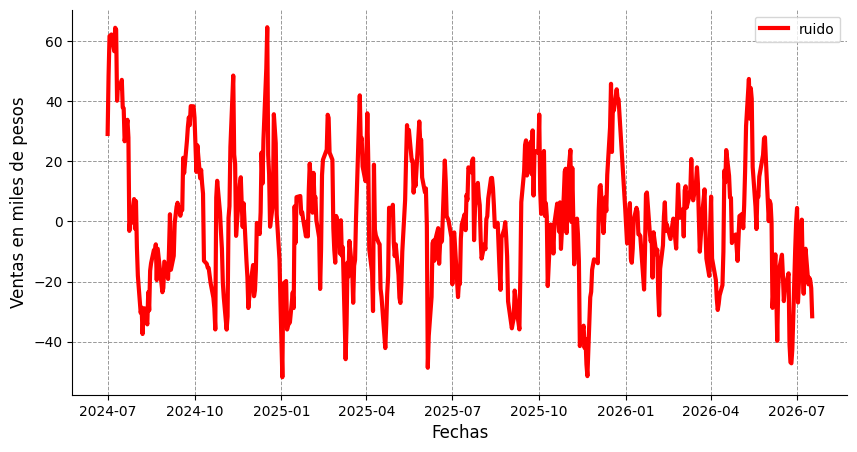

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)


# --- Gráfico de línea ---
plt.plot(
    x, df["ruido_polinomial"],
    color='red',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='ruido'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



## Análisis fundamental (ligero)

**Ejercicio 6**: Realiza una interpretación de los componentes de la serie de tiempo (tendencia, estacionalidad y ruido).

En tu análisis:

+ Explica qué factores externos podrían justificar la tendencia observada (por ejemplo: crecimiento de la empresa, cambios en el mercado, decisiones estratégicas, etc.).
+ Identifica posibles eventos o situaciones que expliquen los patrones de estacionalidad.
+ Reflexiona sobre el ruido, indicando qué tipo de eventos inesperados o aleatorios podrían estar representados en este componente.

Este análisis no requiere un estudio exhaustivo del entorno económico, pero sí una interpretación razonada, similar a un análisis fundamental básico.

Una vez termines, borra estas instrucciones y redacta tus observaciones.

## Aplicaciones

**Ejercicio 7**: Analiza qué personas, empresas o instituciones podrían beneficiarse del análisis realizado.

En tu respuesta:

+ Menciona al menos tres actores (por ejemplo: inversionistas, empresas, instituciones financieras, gobierno, etc.).
+ Explica cómo utilizarían este tipo de análisis.
+ Describe qué beneficios concretos podrían obtener.

Adicionalmente, reflexiona sobre cómo un análisis más profundo podría mejorar estos beneficios o ampliar sus aplicaciones.

Relaciona tu respuesta con los resultados obtenidos en tu análisis (tendencia, estacionalidad y ruido).

Una vez termines, borra estas instrucciones y redacta tus observaciones.